In [ ]:
# [Dataset: IRIS dataset available in sklearn.datasets]
# 1. Implement bisecting K-means clustering on IRIS dataset.
# ● Load the dataset and remove class labels.
# ● Repeatedly split the cluster with the highest SSE.
# ● Continue until k=3 clusters are obtained.
# ● Compute the SSE for each cluster.
# 2. Implement Hierarchical Agglomerative Clustering using single linkage
# (use squared Euclidean distance). Show the dendrogram.

Iris features (first 5 rows):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Bisecting K-Means result (k=3):
Cluster 0: size = 53, SSE = 28.552075
Cluster 1: size = 59, SSE = 31.772203
Cluster 2: size = 38, SSE = 23.879474
Total SSE (sum over clusters) = 84.203753


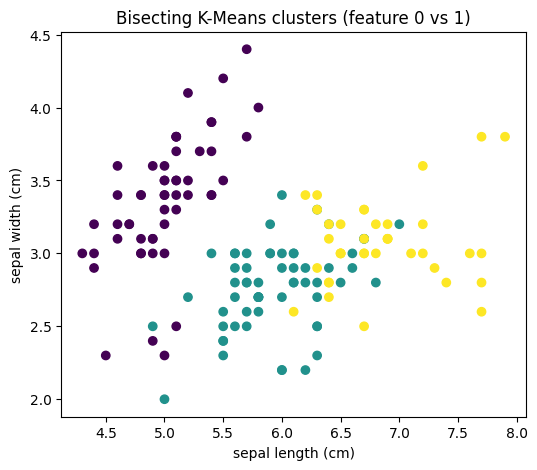

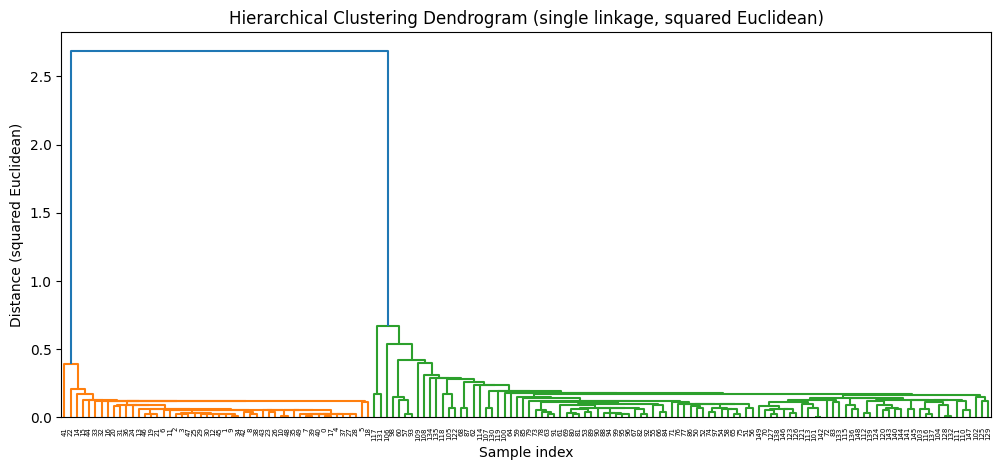


Agglomerative clustering (single linkage) -> SSE per cluster (after cutting to 3 clusters):
Cluster 1: size = 50, SSE = 15.151000
Cluster 2: size = 2, SSE = 0.085000
Cluster 3: size = 98, SSE = 127.243367
Total HAC SSE (sum over clusters) = 142.479367


In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt
import random

iris = load_iris()
X = iris.data.copy()
feature_names = iris.feature_names
df = pd.DataFrame(X, columns=feature_names)

print("Iris features (first 5 rows):")
print(df.head())

def compute_sse(points):
    if len(points) == 0:
        return 0.0, None
    centroid = points.mean(axis=0)
    diffs = points - centroid
    sse = np.sum(np.linalg.norm(diffs, axis=1)**2)
    return float(sse), centroid

def bisecting_kmeans(X, target_k=3, n_init_splits=10, random_state=42, max_iter=300):
    random.seed(random_state)
    np.random.seed(random_state)
    n_samples = X.shape[0]

    clusters = [np.arange(n_samples)]

    while len(clusters) < target_k:
        sse_list = []
        for idx_set in clusters:
            sse_val, _ = compute_sse(X[idx_set])
            sse_list.append(sse_val)
        to_split_idx = int(np.argmax(sse_list))
        to_split_indices = clusters[to_split_idx]
        best_split = None
        best_total_sse = float('inf')

        for trial in range(n_init_splits):
            km = KMeans(n_clusters=2, n_init=1, max_iter=max_iter, random_state=(random_state + trial))
            labels = km.fit_predict(X[to_split_indices])
            idx_part0 = to_split_indices[labels == 0]
            idx_part1 = to_split_indices[labels == 1]
            sse0, _ = compute_sse(X[idx_part0])
            sse1, _ = compute_sse(X[idx_part1])
            total_sse = sse0 + sse1
            if total_sse < best_total_sse:
                best_total_sse = total_sse
                best_split = (idx_part0, idx_part1)
        clusters.pop(to_split_idx)
        clusters.append(best_split[0])
        clusters.append(best_split[1])

    cluster_sse = {}
    for i, idxs in enumerate(clusters):
        sse_val, centroid = compute_sse(X[idxs])
        cluster_sse[i] = {'sse': sse_val, 'size': len(idxs), 'centroid': centroid, 'indices': idxs}

    return clusters, cluster_sse

clusters, cluster_sse = bisecting_kmeans(X, target_k=3, n_init_splits=20, random_state=0)

print("\nBisecting K-Means result (k=3):")
total_sse = 0.0
for cid, info in cluster_sse.items():
    print(f"Cluster {cid}: size = {info['size']}, SSE = {info['sse']:.6f}")
    total_sse += info['sse']
print(f"Total SSE (sum over clusters) = {total_sse:.6f}")

assignments = np.zeros(X.shape[0], dtype=int) - 1
for cid, info in cluster_sse.items():
    assignments[info['indices']] = cid

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=assignments)
plt.title("Bisecting K-Means clusters (feature 0 vs 1)")
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.show()

dist_sq = pdist(X, metric='sqeuclidean')
Z = linkage(dist_sq, method='single')

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode=None)
plt.title("Hierarchical Clustering Dendrogram (single linkage, squared Euclidean)")
plt.xlabel("Sample index")
plt.ylabel("Distance (squared Euclidean)")
plt.show()

labels_hac = fcluster(Z, t=3, criterion='maxclust')
hac_sse = {}
for lab in sorted(np.unique(labels_hac)):
    idxs = np.where(labels_hac == lab)[0]
    sse_val, centroid = compute_sse(X[idxs])
    hac_sse[lab] = {'sse': sse_val, 'size': len(idxs)}

print("\nAgglomerative clustering (single linkage) -> SSE per cluster (after cutting to 3 clusters):")
for lab, info in hac_sse.items():
    print(f"Cluster {lab}: size = {info['size']}, SSE = {info['sse']:.6f}")
total_hac_sse = sum(info['sse'] for info in hac_sse.values())
print(f"Total HAC SSE (sum over clusters) = {total_hac_sse:.6f}")
